In [ ]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA

In [ ]:
# --- 1. Chargement des données prétraitées ---
# Définition du chemin relatif vers le fichier de données nettoyées
# Base_path = os.path.dirname(os.path.dirname(os.path.abspath(__file__)))
path_nettoyage = os.path.join( "..", "data" ,"nettoyage" ,"data_nettoyage.csv")

df = pd.read_csv(path_nettoyage)

# --- 2. Préparation de la matrice de features ---
# Exclusion de la variable cible 'Churn'
# Attention : Veillez à supprimer aussi les ID clients et vérifier que toutes les colonnes sont bien numérisées et standardisées.
X = df.drop(columns=["Churn"])

# Création du dossier de destination s'il n'existe pas
data_cluster = "data/clusters"
os.makedirs(data_cluster, exist_ok=True)



============================ K-means ============================
Nombre de clusters (k):2 | silhouette score:0.23556511188608553
Nombre de clusters (k):3 | silhouette score:0.2842418211475449
Nombre de clusters (k):4 | silhouette score:0.2139998442303234
Nombre de clusters (k):5 | silhouette score:0.19543966367287877
Nombre de clusters (k):6 | silhouette score:0.19003968966389564
Nombre de clusters (k):7 | silhouette score:0.17583815756799323
Nombre de clusters (k):8 | silhouette score:0.17149674557354216
Nombre de clusters (k):9 | silhouette score:0.1591645619349292


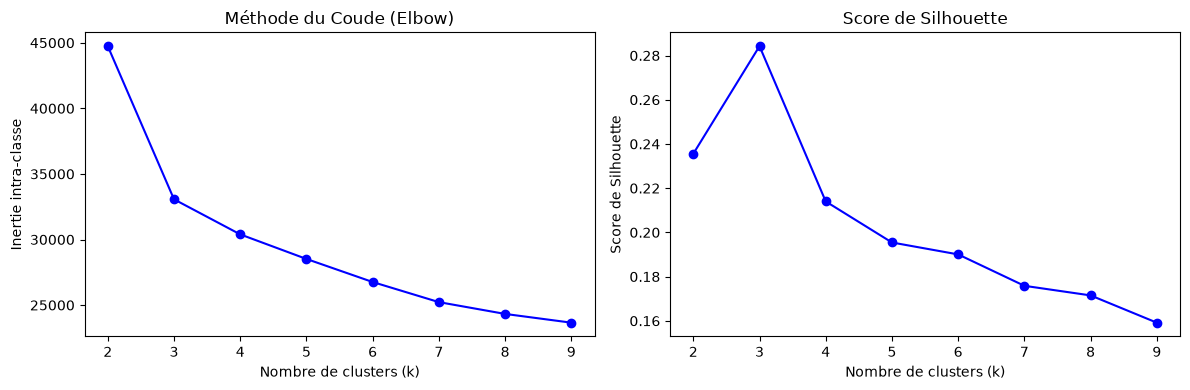

In [ ]:
# --- 3. Recherche du nombre optimal de clusters (k) ---
inerties = []
silhouettes = []
k_Kmeans = range(2, 10)

print("============================ K-means ============================")

# Évaluation de K-Means pour différentes valeurs de k
for k in k_Kmeans:
  Kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
  Kmeans.fit(X)

  # Calcul de l'inertie intra-classe (pour la méthode du coude / Elbow)
  inerties.append(Kmeans.inertia_)

  # Calcul du score de Silhouette (qualité de la séparation des clusters)
  score = silhouette_score(X, Kmeans.labels_)
  silhouettes.append(silhouette_score(X, Kmeans.labels_))

  print(f"Nombre de clusters (k):{k} | silhouette score:{score}")

# --- 4. Visualisation des résultats ---
plt.figure(figsize=(12, 4))

# Graphique 1 : Méthode du coude (Elbow)
plt.subplot(1, 2, 1)
plt.plot(k_Kmeans, inerties, marker="o", color="b")
plt.title("Méthode du Coude (Elbow)")
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Inertie intra-classe")

# Graphique 2 : Score de Silhouette
plt.subplot(1, 2, 2)
plt.plot(k_Kmeans, silhouettes, marker="o", color="b")
plt.title("Score de Silhouette")
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Score de Silhouette")
plt.tight_layout()
plt.show()

In [ ]:
print("============================ DBSCAN ============================")
liste_eps = [0.5, 1, 1.5, 2]
liste_min_samples = [5, 10, 15]

for eps in liste_eps:
  for min_sample in liste_min_samples:
    dbscan = DBSCAN(eps=eps, min_samples=min_sample)
    labels = dbscan.fit_predict(X)

    # Compter les clusters et le bruit (-1)
    nb_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    nb_bruit = list(labels).count(-1)

    if nb_clusters > 1:
        masque = labels != -1
        score = silhouette_score(X[masque], labels[masque])
        score_texte =f"{score:.4f}"

    else:
       score_texte = "N/A moins de 2 clusters"

    print(f"eps={eps} | min_sample={min_sample} --> Clusters trouvés: "
          f"nombre_cluster={nb_clusters} | Bruit={nb_bruit} | Silhouette={score_texte}")



============================ DBSCAN ============================
eps=0.5 | min_sample=5 --> Clusters trouvés: nombre_cluster=118 | Bruit=5896 | Silhouette=0.7840
eps=0.5 | min_sample=10 --> Clusters trouvés: nombre_cluster=36 | Bruit=6447 | Silhouette=0.8095
eps=0.5 | min_sample=15 --> Clusters trouvés: nombre_cluster=12 | Bruit=6723 | Silhouette=0.8533
eps=1 | min_sample=5 --> Clusters trouvés: nombre_cluster=119 | Bruit=5769 | Silhouette=0.5272
eps=1 | min_sample=10 --> Clusters trouvés: nombre_cluster=31 | Bruit=6358 | Silhouette=0.4853
eps=1 | min_sample=15 --> Clusters trouvés: nombre_cluster=8 | Bruit=6672 | Silhouette=0.5379
eps=1.5 | min_sample=5 --> Clusters trouvés: nombre_cluster=18 | Bruit=1109 | Silhouette=-0.0134
eps=1.5 | min_sample=10 --> Clusters trouvés: nombre_cluster=5 | Bruit=1763 | Silhouette=0.0317
eps=1.5 | min_sample=15 --> Clusters trouvés: nombre_cluster=4 | Bruit=2117 | Silhouette=0.1142
eps=2 | min_sample=5 --> Clusters trouvés: nombre_cluster=2 | Bruit=26 

In [ ]:
print("\n============================ Agglomerative Clustering ============================")

list_k = range(2, 10)
for k in list_k:
   model = AgglomerativeClustering(n_clusters=k)
   labels = model.fit_predict(X)
   score = silhouette_score(X, labels)

   print(f"Nombre de clusters (k):{k} | Silhouette score:{score:.4f}")



============================ Agglomerative Clustering ============================
Nombre de clusters (k):2 | Silhouette score:0.2819
Nombre de clusters (k):3 | Silhouette score:0.2816
Nombre de clusters (k):4 | Silhouette score:0.2058
Nombre de clusters (k):5 | Silhouette score:0.1848
Nombre de clusters (k):6 | Silhouette score:0.1740
Nombre de clusters (k):7 | Silhouette score:0.1592
Nombre de clusters (k):8 | Silhouette score:0.1605
Nombre de clusters (k):9 | Silhouette score:0.1543


In [ ]:
print("\n======== Évaluer les clusters avec Silhouette Score et, si pertinent, Davies-Bouldin ou Calinski-Harabasz. ========")

Kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_Kmeans = Kmeans.fit_predict(X)

kmeans_db = davies_bouldin_score(X, labels_Kmeans)
kmeans_ch = calinski_harabasz_score(X, labels_Kmeans)
kmeans_sl = silhouette_score(X, labels_Kmeans)


model = AgglomerativeClustering(n_clusters=3)
labels_agg = model.fit_predict(X)

agg_db = davies_bouldin_score(X, labels_agg)
agg_ch = calinski_harabasz_score(X, labels_agg)
agg_sl = silhouette_score(X, labels_agg)

print("====== K-means")
print(f"davies:{kmeans_db} | calinski:{kmeans_ch} | silhouette:{kmeans_sl}")

print("======  Agglomerative Clustering")
print(f"davies:{agg_db} | calinski:{agg_ch} | silhouette:{agg_sl}")



======== Évaluer les clusters avec Silhouette Score et, si pertinent, Davies-Bouldin ou Calinski-Harabasz. ========
====== K-means
davies:1.3768104476020602 | calinski:2960.7241575551857 | silhouette:0.2842418211475449
======  Agglomerative Clustering
davies:1.371693119041492 | calinski:2836.0535043551386 | silhouette:0.28156682909646485


In [ ]:
print("\n.===================== Interpréter les différents profils de clients =====================")
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
df["Cluster"] = kmeans_final.fit_predict(X)

profils = df.groupby("Cluster").mean()

print("--- MOYENNES PAR CLUSTER ---")
print(profils.T)


.===================== Interpréter les différents profils de clients =====================
--- MOYENNES PAR CLUSTER ---
Cluster                                       0         1         2
SeniorCitizen                          0.200759  0.195601  0.034076
tenure                                 1.116805 -0.656823 -0.074273
MonthlyCharges                         0.810235  0.149069 -1.451829
TotalCharges                           1.339792 -0.508568 -0.713450
Churn                                  0.141908  0.427273  0.074050
gender_Male                            0.499288  0.505572  0.510485
Partner_Yes                            0.694827  0.351906  0.483617
Dependents_Yes                         0.346939  0.215836  0.421363
PhoneService_Yes                       0.917418  0.851026  1.000000
MultipleLines_No phone service         0.082582  0.148974  0.000000
MultipleLines_Yes                      0.693878  0.342229  0.224115
InternetService_Fiber optic            0.617466  0.526393  0.00

In [ ]:
# =====================================================================
#   INTERPRÉTATION DES PROFILS DE CLIENTÈLE (CLUSTERING K-MEANS)
# =====================================================================

"""
L'analyse des moyennes par cluster permet d'identifier 3 profils distincts :

-----------------------------------------------------------------------
1. CLUSTER 0 : « LES CLIENTS VIP / HAUT DE GAMME » (FIDÈLES & PRÉMIUM)
-----------------------------------------------------------------------
- Ancienneté : 81.3% de clients très fidèles 
[Colonnes : Tenure_Group_Fidele, Tenure_Group_Moyen]
- Dépenses : Factures mensuelles (+0.93) et totales (+1.41) très élevées 
  [Colonnes : MonthlyCharges, TotalCharges]
- Services : Très forte souscription aux offres haut de gamme :
  * Fibre optique (67.8%) [Colonne : InternetService_Fiber optic]
  * Streaming TV (76.4%) & Streaming Movies (76.7%) [Colonnes : StreamingTV_Yes, StreamingMovies_Yes]
  * Sauvegarde en ligne (70.4%) & Protection d'équipements (71.5%) [Colonnes : OnlineBackup_Yes, DeviceProtection_Yes]
- Engagement : Forte présence de contrats longs (45.6% sur 2 ans, 30.6% sur 1 an) 
  [Colonnes : Contract_Two year, Contract_One year]
- Risque de Churn : FAIBLE (15.5%) 
  [Colonne : Churn]
- Action Métier : Les maintenir engagés via des programmes de fidélité et récompenses VIP.

-----------------------------------------------------------------------
2. CLUSTER 1 : « LES CLIENTS RÉCENTS À FORT RISQUE DE CHURN » (CRITIQUE)
-----------------------------------------------------------------------
- Ancienneté : Majoritairement des clients récents (46.9%) ou moyens (47.0%) 
  [Colonnes : Tenure_Group_Moyen, Tenure_Group_Fidele]
- Dépenses : Factures mensuelles élevées (+0.11) mais total cumulé faible (-0.47) 
  [Colonnes : MonthlyCharges, TotalCharges]
- Services & Paiement : 
  * 49.7% d'utilisateurs de la Fibre Optique 
  [Colonne : InternetService_Fiber optic]
  * Mode de paiement prédominant : Chèque électronique (46.9%) 
  [Colonne : PaymentMethod_Electronic check]
- Engagement : Abonnements mois par mois (seuls 4.7% ont un contrat de 2 ans) 
  [Colonne : Contract_Two year]
- Risque de Churn : EXTRÊMEMENT ÉLEVÉ (40.8%) 
  [Colonne : Churn]
- Action Métier : PRIORITÉ ABSOLUE. Appliquer des promotions ciblant l'engagement
  sur des contrats de 1 ou 2 ans pour réduire la résiliation.

-----------------------------------------------------------------------
3. CLUSTER 2 : « LES CLIENTS OFFRE BASIQUE / TÉLÉPHONE FIXE » (ÉCONOMIQUES)
-----------------------------------------------------------------------
- Ancienneté : Répartition mixte (anciens, moyens et récents) 
  [Colonnes : Tenure_Group_Moyen, Tenure_Group_Fidele]
- Dépenses : Factures très faibles (-1.45) 
  [Colonne : MonthlyCharges]
- Services : 100% de clients avec ligne fixe uniquement (InternetService_No = 1.0).
  Aucun service Internet ou option multimédia souscrite 
  [Colonnes : InternetService_No, PhoneService_Yes]
- Engagement : Très bonne stabilité (41.8% engagés sur 2 ans) 
  [Colonne : Contract_Two year]
- Risque de Churn : TRÈS FAIBLE (7.4%) 
  [Colonne : Churn]
- Action Métier : Segment passif mais rentable. Maintien de la base sans sur-sollicitation.

-----------------------------------------------------------------------
SYNTHÈSE DU CIBLAGE :
- Cluster 0 -> Fidélisation & Upselling VIP (Risque : 15.5%) [Colonne : Churn]
- Cluster 1 -> Rétention Urgente & Anti-Churn (Risque : 40.8%) [Colonne : Churn]
- Cluster 2 -> Gestion Passive / Offres de base (Risque : 7.4%) [Colonne : Churn]
"""

"\nL'analyse des moyennes par cluster permet d'identifier 3 profils distincts :\n\n-----------------------------------------------------------------------\n1. CLUSTER 0 : « LES CLIENTS VIP / HAUT DE GAMME » (FIDÈLES & PRÉMIUM)\n-----------------------------------------------------------------------\n- Ancienneté : 81.3% de clients très fidèles \n[Colonnes : Tenure_Group_Fidele, Tenure_Group_Moyen]\n- Dépenses : Factures mensuelles (+0.93) et totales (+1.41) très élevées \n  [Colonnes : MonthlyCharges, TotalCharges]\n- Services : Très forte souscription aux offres haut de gamme :\n  * Fibre optique (67.8%) [Colonne : InternetService_Fiber optic]\n  * Streaming TV (76.4%) & Streaming Movies (76.7%) [Colonnes : StreamingTV_Yes, StreamingMovies_Yes]\n  * Sauvegarde en ligne (70.4%) & Protection d'équipements (71.5%) [Colonnes : OnlineBackup_Yes, DeviceProtection_Yes]\n- Engagement : Forte présence de contrats longs (45.6% sur 2 ans, 30.6% sur 1 an) \n  [Colonnes : Contract_Two year, Contra


.===================== Utiliser PCA pour visualiser les clusters =====================


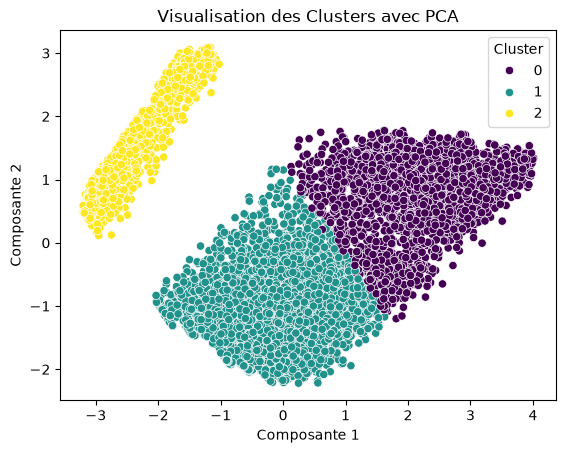

In [ ]:
print("\n.===================== Utiliser PCA pour visualiser les clusters =====================")

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# 2. Visualiser les clusters avec Seaborn
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=df["Cluster"],
    palette="viridis",
    
)

plt.xlabel("Composante 1")
plt.ylabel("Composante 2")
plt.title("Visualisation des Clusters avec PCA")
plt.show()